In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
import time
import datetime
from PIL import Image

# ==========================================
# 0. 全局配置与保存路径
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 确保实验可复现 (毕设必备)
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True # 针对固定尺寸输入加速
set_seed(42)

print(f"🚀 Running on: {DEVICE}")
print(f"📂 Models will be saved to: ./{SAVE_DIR}/")

# ViT 超参数
IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10 # CIFAR-10
NUM_CLASSES_FINETUNE = 6  # NEU-DET

# ==========================================
# 1. 核心架构与【前向特征防御】
# ==========================================
class ForwardDefense(nn.Module):
    """
    【前向防御】(原 MockHE)
    作用：在边缘端特征 Z 上传云端前注入高斯噪声，防御云端的特征逆向重构攻击。
    """
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0 # 预训练时默认关闭 (0.0)，微调时开启

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    """标准的 Transformer Block，使用原生 GELU 激活函数提取最佳特征"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2), #标准是4
            nn.GELU(), 
            nn.Linear(dim * 2, dim) #标准是4
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    """边缘端模型：物理截留原始钢材图像，仅输出加噪特征"""
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        # 边缘端持有前 2 层 Block
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        # 接入前向特征防御
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: 
            x = blk(x)
        # 流出边缘端前进行噪声扰动
        return self.forward_defense(x)

class ServerModel(nn.Module):
    """云端模型：接收中间特征 Z，完成高层语义推断与分类"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 云端持有后 2 层 Block + 分类头
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: 
            x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 数据处理与【反向梯度防御】
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self): 
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        try: 
            img = Image.open(self.file_paths[idx]).convert('RGB')
        except: 
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: 
            img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    """集中式加载并打乱 NEU-DET 数据集 (80% 训练, 20% 测试)"""
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path)
                    labels.append(cls_map[c])
                    break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(
        NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), 
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), 
        batch_size=64, shuffle=False
    )
    
    return train_loader, test_loader

def apply_gradient_defense(grad, prune_ratio=0.5, noise_std=1e-3):
    """
    【反向防御】幅度稀疏化 + 差分隐私加噪
    作用：防止云端利用回传梯度反推边缘端的原始图像 (Model Inversion Attack)。
    """
    if grad is None: 
        return None
    g = grad.detach().clone()
    
    # 1. 梯度剪枝 (过滤掉微小的细节梯度)
    k = int(g.numel() * (1 - prune_ratio))
    if k > 0:
        thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
        mask = g.abs() >= thresh
        g = g * mask
        
    # 2. 差分隐私加噪 (掩盖真实分布)
    noise = torch.randn_like(g) * noise_std
    
    return g + noise

# ==========================================
# 3. 终极训练流程：预训练 -> 双向隐私微调
# ==========================================
def run_ultimate_pipeline():
    # --- A. 阶段 1：全量云端预训练 (CIFAR-10) ---
    print("\n☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...")
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    tf_cifar = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)), 
        transforms.ToTensor(), 
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    t_start = time.time()
    for epoch in range(1, 4):
        client.train(); server.train()
        total_loss = 0
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            # 前向传播 (此时 forward_defense 默认关闭)
            z = client(imgs)
            logits = server(z)
            
            loss = criterion(logits, labels)
            loss.backward()
            opt_c.step(); opt_s.step()
            total_loss += loss.item()
            
        print(f"   Epoch {epoch} (Pre-train) Finished. Avg Loss: {total_loss/len(cifar_loader):.4f}")
        
    print(f"✅ Pre-training Time: {(time.time() - t_start)/60:.1f} minutes")
    
    # --- B. 准备双向防御微调 ---
    print("\n🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...")
    
    # 换头手术 (适配 6 类缺陷)
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    
    # 🌟 开启双向防御之一：前向特征加噪
    client.forward_defense.noise_std = 1e-3
    print("   🛡️ Forward Feature Perturbation: ENABLED")
    print("   🛡️ Backward Gradient DP & Pruning: ENABLED")
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    # 请填入实际的 NEU 数据集路径
    DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
    train_loader, test_loader = load_centralized_data(DATA_ROOT)

    # --- C. 核心微调循环 ---
    best_acc = 0.0
    EPOCHS = 50 
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            # 1. 边缘端前向计算 (此时特征 Z 已被自动加噪保护)
            z = client(imgs)
            
            # 断开计算图，隔离边缘与云端的直接求导关系
            z_payload = z.detach().clone().requires_grad_(True)
            
            # 2. 云端前向计算与反向传播
            logits = server(z_payload)
            loss = criterion(logits, labels)
            loss.backward()
            
            # 3. 🌟 开启双向防御之二：反向梯度防御
            safe_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5, noise_std=1e-3)
            
            opt_s.step() # 云端更新
            
            # 边缘端接收安全的梯度进行更新
            z.backward(safe_grad)
            opt_c.step() 
            
        # --- 全局评估 ---
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        print(f"   Epoch {epoch:02d} (Fine-tune) | 🏆 Test Acc: {acc:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            torch.save(client.state_dict(), f'{SAVE_DIR}/dual_defense_client_best.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/dual_defense_server_best.pth')
            print(f"      🔥 New Best! Model Saved. ({best_acc:.2f}%)")

    print(f"\n✅ Experiment Finished. Final Best Accuracy: {best_acc:.2f}%")
    print(f"📂 Models are ready in: {SAVE_DIR}")

if __name__ == '__main__':
    run_ultimate_pipeline()


libgomp: Invalid value for environment variable OMP_NUM_THREADS


🚀 Running on: cuda
📂 Models will be saved to: ./Dual_Defense_Models/

☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...
Files already downloaded and verified
   Epoch 1 (Pre-train) Finished. Avg Loss: 1.8694
   Epoch 2 (Pre-train) Finished. Avg Loss: 1.6191
   Epoch 3 (Pre-train) Finished. Avg Loss: 1.5060
✅ Pre-training Time: 0.8 minutes

🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...
   🛡️ Forward Feature Perturbation: ENABLED
   🛡️ Backward Gradient DP & Pruning: ENABLED
   Epoch 01 (Fine-tune) | 🏆 Test Acc: 57.22%
      🔥 New Best! Model Saved. (57.22%)
   Epoch 02 (Fine-tune) | 🏆 Test Acc: 68.33%
      🔥 New Best! Model Saved. (68.33%)
   Epoch 03 (Fine-tune) | 🏆 Test Acc: 70.28%
      🔥 New Best! Model Saved. (70.28%)
   Epoch 04 (Fine-tune) | 🏆 Test Acc: 73.61%
      🔥 New Best! Model Saved. (73.61%)
   Epoch 05 (Fine-tune) | 🏆 Test Acc: 79.17%
      🔥 New Best! Model Saved. (79.17%)
   Epoch 06 (Fine-tune) | 🏆 Test Acc: 80.28%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
import time
from PIL import Image

# ==========================================
# 0. 全局配置与复现设置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('Ablation_Models', exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
set_seed(42)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10
NUM_CLASSES_FINETUNE = 6

# 数据路径 (请替换为你的真实路径)
DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 

# ==========================================
# 1. 核心架构与防御机制
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    
    # 如果剪枝率为 0 且噪声为 0，则直接返回原始梯度
    if prune_ratio == 0.0 and noise_std == 0.0:
        return g
        
    # 梯度剪枝
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
            
    # 加噪
    if noise_std > 0.0:
        noise = torch.randn_like(g) * noise_std
        g = g + noise
        
    return g

# ==========================================
# 2. 数据处理
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), batch_size=64, shuffle=False)
    
    return train_loader, test_loader

# ==========================================
# 3. 核心实验引擎 (支持参数化配置)
# ==========================================
def run_experiment(exp_name, config):
    print(f"\n" + "="*60)
    print(f"🔬 启动消融实验: {exp_name}")
    print(f"   配置: {config}")
    print("="*60)
    
    # --- 阶段 1: 重新初始化与全量预训练 ---
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    tf_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    print("☁️ [Stage 1] Pre-training on CIFAR-10...")
    for epoch in range(1, 4): # 为了节省时间，预训练可以少跑几轮
        client.train(); server.train()
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            loss = criterion(server(client(imgs)), labels)
            loss.backward()
            opt_c.step(); opt_s.step()
    
    # --- 阶段 2: 依据配置进行微调 ---
    print(f"🏭 [Stage 2] Finetuning on NEU-DET...")
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    
    # 🌟 设置前向防御参数
    client.forward_defense.noise_std = config['forward_noise']
    
    best_acc = 0.0
    EPOCHS = 50
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone().requires_grad_(True)
            
            logits = server(z_payload)
            loss = criterion(logits, labels)
            loss.backward()
            
            # 🌟 设置反向防御参数
            safe_grad = apply_gradient_defense(
                z_payload.grad, 
                prune_ratio=config['backward_prune'], 
                noise_std=config['backward_noise']
            )
            
            opt_s.step() 
            z.backward(safe_grad)
            opt_c.step() 
            
        # 全局评估
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        
        if acc > best_acc:
            best_acc = acc
            # 可选: 保存每个消融实验的最佳模型
            # torch.save(client.state_dict(), f'Ablation_Models/{exp_name}_client.pth')
            # torch.save(server.state_dict(), f'Ablation_Models/{exp_name}_server.pth')

    print(f"✅ {exp_name} Finished. Best Accuracy: {best_acc:.2f}%")
    return best_acc

# ==========================================
# 4. 执行所有消融实验
# ==========================================
if __name__ == '__main__':
    # 定义四个实验配置
    experiments = {
        "A. 基线未加保护 (Baseline)": {
            "forward_noise": 0.0,       # 关闭前向加噪
            "backward_prune": 0.0,      # 关闭反向剪枝
            "backward_noise": 0.0       # 关闭反向加噪
        },
        "B. 仅前向特征扰动 (Forward Only)": {
            "forward_noise": 1e-3,      # 开启前向加噪
            "backward_prune": 0.0,      # 关闭反向剪枝
            "backward_noise": 0.0       # 关闭反向加噪
        },
        "C. 仅反向梯度保护 (Backward Only)": {
            "forward_noise": 0.0,       # 关闭前向加噪
            "backward_prune": 0.5,      # 开启反向剪枝
            "backward_noise": 1e-3      # 开启反向加噪
        },
        "D. 本文方法: 双向保护 (Dual Defense)": {
            "forward_noise": 1e-3,      # 开启前向加噪
            "backward_prune": 0.5,      # 开启反向剪枝
            "backward_noise": 1e-3      # 开启反向加噪
        }
    }
    
    results = {}
    
    # 依次运行所有实验
    for name, config in experiments.items():
        # 注意重新设置随机种子，保证每次初始化起点一致
        set_seed(42) 
        best_acc = run_experiment(name, config)
        results[name] = best_acc
        
    # 输出最终的消融实验报告
    print("\n\n" + "="*60)
    print("📊 最终消融实验结果报告")
    print("="*60)
    print(f"{'实验组别':<35} | {'最佳精度 (Best Acc)'}")
    print("-" * 60)
    for name, acc in results.items():
        print(f"{name:<35} | {acc:>15.2f}%")
    print("="*60)


🔬 启动消融实验: A. 基线未加保护 (Baseline)
   配置: {'forward_noise': 0.0, 'backward_prune': 0.0, 'backward_noise': 0.0}
Files already downloaded and verified
☁️ [Stage 1] Pre-training on CIFAR-10...
🏭 [Stage 2] Finetuning on NEU-DET...
✅ A. 基线未加保护 (Baseline) Finished. Best Accuracy: 92.78%

🔬 启动消融实验: B. 仅前向特征扰动 (Forward Only)
   配置: {'forward_noise': 0.001, 'backward_prune': 0.0, 'backward_noise': 0.0}
Files already downloaded and verified
☁️ [Stage 1] Pre-training on CIFAR-10...
🏭 [Stage 2] Finetuning on NEU-DET...
✅ B. 仅前向特征扰动 (Forward Only) Finished. Best Accuracy: 92.50%

🔬 启动消融实验: C. 仅反向梯度保护 (Backward Only)
   配置: {'forward_noise': 0.0, 'backward_prune': 0.5, 'backward_noise': 0.001}
Files already downloaded and verified
☁️ [Stage 1] Pre-training on CIFAR-10...
🏭 [Stage 2] Finetuning on NEU-DET...
✅ C. 仅反向梯度保护 (Backward Only) Finished. Best Accuracy: 89.72%

🔬 启动消融实验: D. 本文方法: 双向保护 (Dual Defense)
   配置: {'forward_noise': 0.001, 'backward_prune': 0.5, 'backward_noise': 0.001}
Files already dow

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
from PIL import Image

# ==========================================
# 0. 全局配置与复现设置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Ablation_Models'
os.makedirs(SAVE_DIR, exist_ok=True) # 文件夹必须建好

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
set_seed(42)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10
NUM_CLASSES_FINETUNE = 6

# 数据路径 (请替换为你的真实路径)
DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 

# ==========================================
# 1. 核心架构与防御机制
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    
    if prune_ratio == 0.0 and noise_std == 0.0:
        return g
        
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
            
    if noise_std > 0.0:
        noise = torch.randn_like(g) * noise_std
        g = g + noise
        
    return g

# ==========================================
# 2. 数据处理
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), batch_size=64, shuffle=False)
    
    return train_loader, test_loader

# ==========================================
# 3. 核心实验引擎 (带真实保存机制)
# ==========================================
def run_experiment(exp_key, exp_desc, config):
    print(f"\n" + "="*60)
    print(f"🔬 启动消融实验: {exp_desc}")
    print(f"   配置: {config}")
    print("="*60)
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    tf_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    print("☁️ [Stage 1] Pre-training on CIFAR-10...")
    for epoch in range(1, 4): 
        client.train(); server.train()
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            loss = criterion(server(client(imgs)), labels)
            loss.backward()
            opt_c.step(); opt_s.step()
    
    print(f"🏭 [Stage 2] Finetuning on NEU-DET...")
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    
    # 🌟 设置前向防御参数
    client.forward_defense.noise_std = config['forward_noise']
    
    best_acc = 0.0
    EPOCHS = 50
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone().requires_grad_(True)
            
            logits = server(z_payload)
            loss = criterion(logits, labels)
            loss.backward()
            
            # 🌟 设置反向防御参数
            safe_grad = apply_gradient_defense(
                z_payload.grad, 
                prune_ratio=config['backward_prune'], 
                noise_std=config['backward_noise']
            )
            
            opt_s.step() 
            z.backward(safe_grad)
            opt_c.step() 
            
        # 全局评估
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        
        # 🚨【修改点】真实执行模型保存操作，使用安全的英文短名作为文件名
        if acc > best_acc:
            best_acc = acc
            torch.save(client.state_dict(), f'{SAVE_DIR}/{exp_key}_client_best.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/{exp_key}_server_best.pth')
            print(f"   Epoch {epoch:02d} | 🔥 New Best: {acc:.2f}% (Saved to {exp_key}_*_best.pth)")

    print(f"✅ {exp_desc} Finished. Best Accuracy: {best_acc:.2f}%")
    return best_acc

# ==========================================
# 4. 执行所有消融实验
# ==========================================
if __name__ == '__main__':
    # 定义四个实验配置：使用英文短名作为 key（用于保存文件），长描述作为值
    experiments = {
        "Exp_A_Baseline": {
            "desc": "基线未加保护 (Baseline)",
            "forward_noise": 0.0,       
            "backward_prune": 0.0,      
            "backward_noise": 0.0       
        },
        "Exp_B_ForwardOnly": {
            "desc": "拆分学习 + 前向特征扰动",
            "forward_noise": 1e-3,      
            "backward_prune": 0.0,      
            "backward_noise": 0.0       
        },
        "Exp_C_BackwardOnly": {
            "desc": "拆分学习 + 反向梯度保护",
            "forward_noise": 0.0,       
            "backward_prune": 0.5,      
            "backward_noise": 1e-3      
        },
        "Exp_D_DualDefense": {
            "desc": "本文方法 (双向保护)",
            "forward_noise": 1e-3,      
            "backward_prune": 0.5,      
            "backward_noise": 1e-3      
        }
    }
    
    results = {}
    
    # 依次运行所有实验
    for exp_key, config in experiments.items():
        # 注意重新设置随机种子，保证每次初始化起点完全一致
        set_seed(42) 
        best_acc = run_experiment(exp_key, config['desc'], config)
        results[config['desc']] = best_acc
        
    # 输出最终的消融实验报告
    print("\n\n" + "="*60)
    print("📊 最终消融实验结果报告")
    print("="*60)
    print(f"{'实验组别':<35} | {'最佳精度 (Best Acc)'}")
    print("-" * 60)
    for desc, acc in results.items():
        print(f"{desc:<35} | {acc:>15.2f}%")
    print("="*60)
    print(f"📂 所有消融实验的权重文件已安全保存在: ./{SAVE_DIR}/ 目录下。")


🔬 启动消融实验: 基线未加保护 (Baseline)
   配置: {'desc': '基线未加保护 (Baseline)', 'forward_noise': 0.0, 'backward_prune': 0.0, 'backward_noise': 0.0}
Files already downloaded and verified
☁️ [Stage 1] Pre-training on CIFAR-10...
🏭 [Stage 2] Finetuning on NEU-DET...
   Epoch 01 | 🔥 New Best: 66.67% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 02 | 🔥 New Best: 76.11% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 03 | 🔥 New Best: 81.39% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 04 | 🔥 New Best: 84.17% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 05 | 🔥 New Best: 86.39% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 07 | 🔥 New Best: 87.78% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 08 | 🔥 New Best: 88.89% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 09 | 🔥 New Best: 90.00% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 11 | 🔥 New Best: 90.28% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 14 | 🔥 New Best: 90.56% (Saved to Exp_A_Baseline_*_best.pth)
   Epoch 17 | 🔥 New Best: 91.11% (Saved to Exp_A_B

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
import time
import datetime
from PIL import Image

# ==========================================
# 0. 全局配置与复现设置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Standard_Baseline_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
set_seed(42)

print(f"🚀 Running on: {DEVICE}")

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10
NUM_CLASSES_FINETUNE = 6

# ==========================================
# 1. 核心架构 (标准单体 ViT，无拆分)
# ==========================================
class StandardBlock(nn.Module):
    """标准的 Transformer Block，使用原生 GELU 激活函数"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class StandardViT(nn.Module):
    """
    最基础的端到端 ViT 模型
    将原本拆分在边缘(2层)和云端(2层)的结构合二为一，共 4 层 Block
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Patch Embedding
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        
        # 连续的 4 层 Transformer Block (不再拆分)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(4)])
        
        # 归一化与分类头
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: 
            x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 数据处理
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), batch_size=64, shuffle=False)
    
    return train_loader, test_loader

# ==========================================
# 3. 基础训练流程
# ==========================================
def run_standard_baseline():
    print(f"\n" + "="*60)
    print(f"🔬 启动绝对基准实验: 集中式单体 ViT (无拆分, 无防御)")
    print("="*60)
    
    # 实例化单体模型并放入 GPU
    model = StandardViT(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    # --- 阶段 1: 全量预训练 ---
    tf_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    print("☁️ [Stage 1] Pre-training on CIFAR-10...")
    for epoch in range(1, 4): 
        model.train()
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            # 最基础的端到端前向传播
            logits = model(imgs)
            loss = criterion(logits, labels)
            
            # 最基础的反向传播 (没有 z_payload 的断图和加噪)
            loss.backward()
            optimizer.step()
    
    # --- 阶段 2: 目标数据集微调 ---
    print(f"🏭 [Stage 2] Finetuning on NEU-DET...")
    
    # 换头手术 (10 -> 6)
    model.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    # 微调使用更低的学习率
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    # 请填入实际的 NEU 数据集路径
    DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    
    best_acc = 0.0
    EPOCHS = 50
    
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            # 端到端前向与反向传播
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
        # 全局评估
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        
        # 保存最佳模型
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f'{SAVE_DIR}/Absolute_Baseline_best.pth')
            print(f"   Epoch {epoch:02d} | 🔥 New Best: {acc:.2f}% (Saved to Absolute_Baseline_best.pth)")

    print(f"✅ Absolute Baseline Finished. Best Accuracy (The Upper Bound): {best_acc:.2f}%")
    return best_acc

if __name__ == '__main__':
    run_standard_baseline()

🚀 Running on: cuda

🔬 启动绝对基准实验: 集中式单体 ViT (无拆分, 无防御)
Files already downloaded and verified
☁️ [Stage 1] Pre-training on CIFAR-10...
🏭 [Stage 2] Finetuning on NEU-DET...
   Epoch 01 | 🔥 New Best: 66.67% (Saved to Absolute_Baseline_best.pth)
   Epoch 02 | 🔥 New Best: 76.11% (Saved to Absolute_Baseline_best.pth)
   Epoch 03 | 🔥 New Best: 81.39% (Saved to Absolute_Baseline_best.pth)
   Epoch 04 | 🔥 New Best: 84.17% (Saved to Absolute_Baseline_best.pth)
   Epoch 05 | 🔥 New Best: 86.39% (Saved to Absolute_Baseline_best.pth)
   Epoch 07 | 🔥 New Best: 87.50% (Saved to Absolute_Baseline_best.pth)
   Epoch 08 | 🔥 New Best: 88.61% (Saved to Absolute_Baseline_best.pth)
   Epoch 09 | 🔥 New Best: 89.44% (Saved to Absolute_Baseline_best.pth)
   Epoch 10 | 🔥 New Best: 90.00% (Saved to Absolute_Baseline_best.pth)
   Epoch 14 | 🔥 New Best: 90.56% (Saved to Absolute_Baseline_best.pth)
   Epoch 17 | 🔥 New Best: 90.83% (Saved to Absolute_Baseline_best.pth)
   Epoch 24 | 🔥 New Best: 91.11% (Saved to Absolut

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Ablation_Models'

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明模型组件 (用于加载权重)
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        if self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
    if noise_std > 0.0:
        g = g + torch.randn_like(g) * noise_std
    return g

# 计算 PSNR (峰值信噪比)
def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    # 图像经过标准化，范围大致在 [-1, 1]，因此 max_pixel 为 2
    psnr = 20 * np.log10(2.0 / np.sqrt(mse))
    return psnr

# ==========================================
# 2. 核心攻击算法 (白盒联合重构攻击)
# ==========================================
def reconstruct_attack(client_model, real_img, config, iters=300):
    """
    模拟恶意云端，通过截获的特征Z和梯度G，反向优化出一张假图像(dummy_img)，
    使其产生的特征和梯度尽可能逼近截获的数据。
    """
    client_model.eval() # 冻结边缘模型
    
    # --- A. 截获数据阶段 (Interception) ---
    real_img = real_img.to(DEVICE)
    real_img.requires_grad_(True)
    
    # 边缘端进行前向防御
    client_model.forward_defense.noise_std = config['forward_noise']
    z_real = client_model(real_img)
    
    # 模拟云端产生了一个随机的回传梯度 (在实际中这是由Server的Loss产生的)
    fake_loss = z_real.mean()
    fake_loss.backward(retain_graph=True)
    
    # 边缘端进行反向防御
    intercepted_z = z_real.detach().clone()
    intercepted_grad = apply_gradient_defense(real_img.grad, config['backward_prune'], config['backward_noise']).detach().clone()
    
    # --- B. 攻击优化阶段 (Optimization) ---
    # 恶意云端初始化一张全噪声的假图片
    dummy_img = torch.randn_like(real_img).to(DEVICE)
    dummy_img.requires_grad_(True)
    
    # 攻击者使用 Adam 优化器调整这块“橡皮泥”，试图捏成原图的形状
    optimizer = optim.Adam([dummy_img], lr=0.1)
    criterion = nn.MSELoss()
    
    # 恶意云端不需要考虑边缘端的防御(设为0)，因为它只是在自己本地用白盒模型拟合
    client_model.forward_defense.noise_std = 0.0 
    
    print("   [Attacker] 正在进行梯度与特征联合匹配优化...")
    for i in range(iters):
        optimizer.zero_grad()
        
        # 假图像产生的特征
        dummy_z = client_model(dummy_img)
        
        # 损失1: 特征匹配 (企图破解前向传播)
        loss_z = criterion(dummy_z, intercepted_z)
        
        # 损失2: 梯度匹配 (企图破解反向传播)
        dummy_loss = dummy_z.mean()
        dummy_grad = torch.autograd.grad(dummy_loss, dummy_img, create_graph=True)[0]
        loss_g = criterion(dummy_grad, intercepted_grad)
        
        # 联合攻击目标
        total_loss = loss_z + loss_g
        total_loss.backward()
        optimizer.step()
        
        # 限制像素范围 [-1, 1]
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
    # 计算攻击结果的 PSNR
    final_psnr = calculate_psnr(real_img, dummy_img)
    return dummy_img.detach().cpu(), final_psnr

# ==========================================
# 3. 执行评估
# ==========================================
def run_all_attacks():
    print("="*60)
    print("🏴‍☠️ 启动模型隐私重构攻击评估 (Model Inversion Attack)")
    print("="*60)
    
    # 获取一张真实的测试图像
    # 注意：你需要随便找一张你的数据集里的图片路径放这里
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    
    experiments = {
        "Exp_A_Baseline": {"desc": "A. 基线未加保护", "forward_noise": 0.0, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_B_ForwardOnly": {"desc": "B. 仅前向特征扰动", "forward_noise": 1e-3, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_C_BackwardOnly": {"desc": "C. 仅反向梯度保护", "forward_noise": 0.0, "backward_prune": 0.5, "backward_noise": 1e-3},
        "Exp_D_DualDefense": {"desc": "D. 本文双向防御", "forward_noise": 1e-3, "backward_prune": 0.5, "backward_noise": 1e-3}
    }
    
    results = {}
    reconstructed_imgs = {}
    
    client_model = ClientModel().to(DEVICE)
    
    for key, config in experiments.items():
        print(f"\n🎯 正在攻击: {config['desc']}")
        weight_path = os.path.join(SAVE_DIR, f"{key}_client_best.pth")
        
        if not os.path.exists(weight_path):
            print(f"   ⚠️ 未找到权重文件: {weight_path}，跳过此项。")
            continue
            
        client_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        
        # 运行攻击
        dummy_img, psnr = reconstruct_attack(client_model, real_img, config, iters=300)
        results[config['desc']] = psnr
        reconstructed_imgs[config['desc']] = dummy_img.squeeze()
        
        print(f"   🛡️ 攻击结束。重构图像 PSNR: {psnr:.2f} dB (越低说明防御越好)")

    # 打印总结表
    print("\n" + "="*60)
    print("📊 隐私防御能力评估报告 (对抗攻击结果)")
    print("="*60)
    print(f"{'实验组别':<35} | {'重构图像 PSNR (dB)'}")
    print("-" * 60)
    for desc, psnr in results.items():
        print(f"{desc:<35} | {psnr:>15.2f}")
    print("="*60)
    print("💡 注解：PSNR 越低，说明攻击者还原出的图像全是噪点，无法辨认。")

if __name__ == "__main__":
    run_all_attacks()

🏴‍☠️ 启动模型隐私重构攻击评估 (Model Inversion Attack)

🎯 正在攻击: A. 基线未加保护
   [Attacker] 正在进行梯度与特征联合匹配优化...
   🛡️ 攻击结束。重构图像 PSNR: 10.57 dB (越低说明防御越好)

🎯 正在攻击: B. 仅前向特征扰动
   [Attacker] 正在进行梯度与特征联合匹配优化...
   🛡️ 攻击结束。重构图像 PSNR: 10.42 dB (越低说明防御越好)

🎯 正在攻击: C. 仅反向梯度保护
   [Attacker] 正在进行梯度与特征联合匹配优化...
   🛡️ 攻击结束。重构图像 PSNR: 11.09 dB (越低说明防御越好)

🎯 正在攻击: D. 本文双向防御
   [Attacker] 正在进行梯度与特征联合匹配优化...
   🛡️ 攻击结束。重构图像 PSNR: 10.75 dB (越低说明防御越好)

📊 隐私防御能力评估报告 (对抗攻击结果)
实验组别                                | 重构图像 PSNR (dB)
------------------------------------------------------------
A. 基线未加保护                           |           10.57
B. 仅前向特征扰动                          |           10.42
C. 仅反向梯度保护                          |           11.09
D. 本文双向防御                           |           10.75
💡 注解：PSNR 越低，说明攻击者还原出的图像全是噪点，无法辨认。


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Ablation_Models'
OUT_DIR = 'Attack_Results'  # 🌟 所有的可视化图片都会存在这里
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明模型组件
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        if self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
    if noise_std > 0.0:
        g = g + torch.randn_like(g) * noise_std
    return g

# ==========================================
# 2. 辅助函数：图像反标准化与绘图
# ==========================================
def denorm(tensor):
    """将 [-1, 1] 的张量转换回 [0, 1] 用于显示"""
    t = tensor.detach().cpu().squeeze(0).clamp(-1, 1)
    return (t * 0.5 + 0.5).permute(1, 2, 0).numpy()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    psnr = 20 * np.log10(2.0 / np.sqrt(mse)) # 因为我们的值域是 [-1, 1]，跨度是2
    return psnr

def total_variation_loss(img):
    """🌟 核心武器：TV正则化，逼迫图像变得平滑自然，消除雪花点"""
    tv_h = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    tv_w = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return tv_h + tv_w

# ==========================================
# 3. 高阶攻击算法 (带可视化存储)
# ==========================================
def reconstruct_attack_advanced(client_model, real_img, config, exp_name, iters=500):
    client_model.eval()
    
    # --- A. 截获数据 ---
    real_img = real_img.to(DEVICE).requires_grad_(True)
    client_model.forward_defense.noise_std = config['forward_noise']
    z_real = client_model(real_img)
    
    fake_loss = z_real.mean()
    fake_loss.backward(retain_graph=True)
    
    intercepted_z = z_real.detach().clone()
    intercepted_grad = apply_gradient_defense(real_img.grad, config['backward_prune'], config['backward_noise']).detach().clone()
    
    # --- B. 攻击优化 ---
    # 🌟 使用随机高斯噪声作为起点
    dummy_img = torch.randn_like(real_img).to(DEVICE).requires_grad_(True)
    
    # 🌟 降低学习率，使用更稳定的优化配置
    optimizer = optim.Adam([dummy_img], lr=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    criterion = nn.MSELoss()
    
    client_model.forward_defense.noise_std = 0.0 
    
    # 存储攻击过程中的图像快照
    process_snapshots = []
    log_intervals = [0, 50, 100, 200, 300, 499]
    
    print(f"   [Attacker] 正在实施高级白盒重构攻击 ({exp_name})...")
    
    for i in range(iters):
        optimizer.zero_grad()
        dummy_z = client_model(dummy_img)
        
        # 特征与梯度匹配损失
        loss_z = criterion(dummy_z, intercepted_z)
        dummy_loss = dummy_z.mean()
        dummy_grad = torch.autograd.grad(dummy_loss, dummy_img, create_graph=True)[0]
        loss_g = criterion(dummy_grad, intercepted_grad)
        
        # 🌟 引入图像平滑先验 (TV Loss)
        tv_penalty = 1e-3 * total_variation_loss(dummy_img)
        
        # 综合损失 (在特征和梯度匹配的同时，强制图像保持真实观感)
        total_loss = loss_z + loss_g + tv_penalty
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        # 限幅处理
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
        if i in log_intervals:
            process_snapshots.append(denorm(dummy_img))
            
    final_psnr = calculate_psnr(real_img, dummy_img)
    
    # 🌟 绘制并保存单次攻击的演变过程图
    fig, axes = plt.subplots(1, len(log_intervals), figsize=(15, 3))
    fig.suptitle(f'Reconstruction Process: {exp_name} (Final PSNR: {final_psnr:.2f}dB)', fontsize=14)
    for idx, ax in enumerate(axes):
        ax.imshow(process_snapshots[idx])
        ax.set_title(f'Iter {log_intervals[idx]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'Process_{exp_name}.png'))
    plt.close()
    
    return dummy_img.detach(), final_psnr

# ==========================================
# 4. 执行所有评估并生成总对比图
# ==========================================
def run_all_attacks():
    print("="*60)
    print("🏴‍☠️ 启动高级特征与梯度联合重构攻击评估")
    print("="*60)
    
    # 换成你真实存在的图片路径
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    if not os.path.exists(img_path):
        print(f"❌ 找不到图片: {img_path}")
        return
        
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    
    experiments = {
        "Exp_A_Baseline": {"desc": "Baseline", "forward_noise": 0.0, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_B_ForwardOnly": {"desc": "Forward Perturb", "forward_noise": 1e-3, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_C_BackwardOnly": {"desc": "Backward Prune+DP", "forward_noise": 0.0, "backward_prune": 0.5, "backward_noise": 1e-3},
        "Exp_D_DualDefense": {"desc": "Dual Defense (Ours)", "forward_noise": 1e-3, "backward_prune": 0.5, "backward_noise": 1e-3}
    }
    
    results = {}
    reconstructed_imgs = {}
    client_model = ClientModel().to(DEVICE)
    
    for key, config in experiments.items():
        print(f"\n🎯 目标: {config['desc']}")
        weight_path = os.path.join(SAVE_DIR, f"{key}_client_best.pth")
        
        if not os.path.exists(weight_path):
            print(f"   ⚠️ 未找到权重: {weight_path}，请先跑消融代码！")
            continue
            
        client_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        
        dummy_img, psnr = reconstruct_attack_advanced(client_model, real_img, config, key, iters=500)
        results[config['desc']] = psnr
        reconstructed_imgs[config['desc']] = denorm(dummy_img)
        
        print(f"   🛡️ 攻击结束。最终 PSNR: {psnr:.2f} dB")

    # 🌟 绘制总的防守能力对比图 (极其适合放到论文里)
    if reconstructed_imgs:
        fig, axes = plt.subplots(1, len(reconstructed_imgs) + 1, figsize=(15, 4))
        fig.suptitle('Privacy Defense Capability Comparison', fontsize=16, fontweight='bold')
        
        # 原图
        axes[0].imshow(denorm(real_img))
        axes[0].set_title("Original Image\n(Ground Truth)")
        axes[0].axis('off')
        
        # 各个重构结果
        for idx, (desc, img) in enumerate(reconstructed_imgs.items()):
            axes[idx+1].imshow(img)
            axes[idx+1].set_title(f"{desc}\nPSNR: {results[desc]:.2f} dB")
            axes[idx+1].axis('off')
            
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, 'Final_Defense_Comparison.png'), dpi=300)
        plt.close()
        print(f"\n✅ 评估完成！所有的过程图和终极对比图已保存在 📂 ./{OUT_DIR}/ 文件夹下。")

if __name__ == "__main__":
    run_all_attacks()

🏴‍☠️ 启动高级特征与梯度联合重构攻击评估

🎯 目标: Baseline
   [Attacker] 正在实施高级白盒重构攻击 (Exp_A_Baseline)...
   🛡️ 攻击结束。最终 PSNR: 19.10 dB

🎯 目标: Forward Perturb
   [Attacker] 正在实施高级白盒重构攻击 (Exp_B_ForwardOnly)...
   🛡️ 攻击结束。最终 PSNR: 19.61 dB

🎯 目标: Backward Prune+DP
   [Attacker] 正在实施高级白盒重构攻击 (Exp_C_BackwardOnly)...
   🛡️ 攻击结束。最终 PSNR: 21.98 dB

🎯 目标: Dual Defense (Ours)
   [Attacker] 正在实施高级白盒重构攻击 (Exp_D_DualDefense)...
   🛡️ 攻击结束。最终 PSNR: 20.47 dB

✅ 评估完成！所有的过程图和终极对比图已保存在 📂 ./Attack_Results/ 文件夹下。


🏴‍☠️ 启动绝对基线攻击 (无拆分 DLG 梯度泄露)
   [Attacker] 正在实施 DLG 全模型梯度深度泄露攻击...
   🛡️ DLG 攻击结束！最终 PSNR: 8.09 dB
✅ 结果已保存至 📂 Attack_Results/Final_DLG_Absolute_Baseline.png


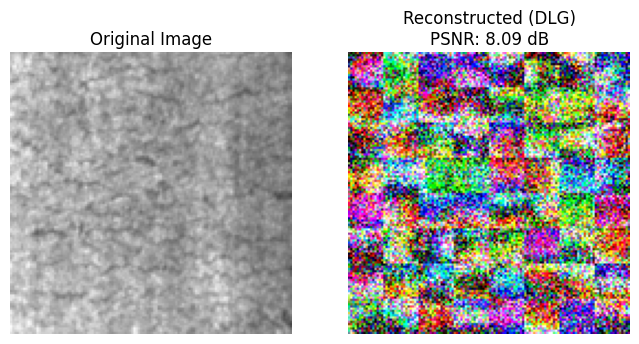

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Standard_Baseline_Models'
OUT_DIR = 'Attack_Results'
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明绝对基线模型
# ==========================================
class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class StandardViT(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(4)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 辅助函数
# ==========================================
def denorm(tensor):
    t = tensor.detach().cpu().squeeze(0).clamp(-1, 1)
    return (t * 0.5 + 0.5).permute(1, 2, 0).numpy()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    return 20 * np.log10(2.0 / np.sqrt(mse))

def total_variation_loss(img):
    tv_h = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    tv_w = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return tv_h + tv_w

# ==========================================
# 3. DLG (Deep Leakage from Gradients) 攻击
# ==========================================
def reconstruct_dlg_attack(model, real_img, real_label, iters=500):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    # --- A. 截获数据 (恶意服务器截获了客户端传来的全模型梯度) ---
    real_img = real_img.to(DEVICE)
    real_label = real_label.to(DEVICE)
    
    # 模拟客户端计算并发送梯度
    real_logits = model(real_img)
    real_loss = criterion(real_logits, real_label)
    real_grads = torch.autograd.grad(real_loss, model.parameters())
    # 截获的真实梯度
    intercepted_grads = [g.detach().clone() for g in real_grads]
    
    # --- B. 攻击优化 (服务器试图伪造图片匹配梯度) ---
    dummy_img = torch.randn_like(real_img).to(DEVICE).requires_grad_(True)
    optimizer = optim.Adam([dummy_img], lr=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    
    process_snapshots = []
    log_intervals = [0, 50, 100, 200, 300, 499]
    
    print("   [Attacker] 正在实施 DLG 全模型梯度深度泄露攻击...")
    
    for i in range(iters):
        optimizer.zero_grad()
        
        # 伪造图片产生伪造梯度
        dummy_logits = model(dummy_img)
        dummy_loss = criterion(dummy_logits, real_label)
        dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
        
        # 🌟 核心攻击损失：计算伪造梯度与截获梯度的 MSE 差异
        grad_diff = 0
        for gx, gy in zip(dummy_grads, intercepted_grads):
            grad_diff += ((gx - gy) ** 2).sum()
            
        # TV 图像平滑正则化
        tv_penalty = 1e-3 * total_variation_loss(dummy_img)
        total_loss = grad_diff + tv_penalty
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
        if i in log_intervals:
            process_snapshots.append(denorm(dummy_img))
            
    final_psnr = calculate_psnr(real_img, dummy_img)
    
    # 绘制过程图
    fig, axes = plt.subplots(1, len(log_intervals), figsize=(15, 3))
    fig.suptitle(f'DLG Attack on StandardViT (Final PSNR: {final_psnr:.2f}dB)', fontsize=14)
    for idx, ax in enumerate(axes):
        ax.imshow(process_snapshots[idx])
        ax.set_title(f'Iter {log_intervals[idx]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'Process_Absolute_Baseline_DLG.png'))
    plt.close()
    
    return dummy_img.detach(), final_psnr

# ==========================================
# 4. 执行攻击
# ==========================================
if __name__ == "__main__":
    print("="*60)
    print("🏴‍☠️ 启动绝对基线攻击 (无拆分 DLG 梯度泄露)")
    print("="*60)
    
    # 请填写真实图片路径
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    real_label = torch.tensor([0]) # 假设 crazing 是类别 0，DLG 攻击通常假设知道标签
    
    model = StandardViT(num_classes=6).to(DEVICE)
    weight_path = os.path.join(SAVE_DIR, "Absolute_Baseline_best.pth")
    
    if not os.path.exists(weight_path):
        print(f"❌ 找不到权重: {weight_path}，请先运行 standard_vit_baseline.py")
    else:
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        dummy_img, psnr = reconstruct_dlg_attack(model, real_img, real_label, iters=500)
        
        print(f"   🛡️ DLG 攻击结束！最终 PSNR: {psnr:.2f} dB")
        
        # 画出对比图
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(denorm(real_img))
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        axes[1].imshow(denorm(dummy_img))
        axes[1].set_title(f"Reconstructed (DLG)\nPSNR: {psnr:.2f} dB")
        axes[1].axis('off')
        plt.savefig(os.path.join(OUT_DIR, 'Final_DLG_Absolute_Baseline.png'))
        print(f"✅ 结果已保存至 📂 {OUT_DIR}/Final_DLG_Absolute_Baseline.png")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
import time
import datetime
from PIL import Image

# ==========================================
# 0. 全局配置与保存路径
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 确保实验可复现 (毕设必备)
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True # 针对固定尺寸输入加速
set_seed(42)

print(f"🚀 Running on: {DEVICE}")
print(f"📂 Models will be saved to: ./{SAVE_DIR}/")

# ViT 超参数
IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10 # CIFAR-10
NUM_CLASSES_FINETUNE = 6  # NEU-DET

# ==========================================
# 1. 核心架构与【前向特征防御】
# ==========================================
class ForwardDefense(nn.Module):
    """
    【前向防御】(原 MockHE)
    作用：在边缘端特征 Z 上传云端前注入高斯噪声，防御云端的特征逆向重构攻击。
    """
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0 # 预训练时默认关闭 (0.0)，微调时开启

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    """标准的 Transformer Block，使用原生 GELU 激活函数提取最佳特征"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(), 
            nn.Linear(dim * 2, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    """边缘端模型：物理截留原始钢材图像，仅输出加噪特征"""
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        # 边缘端持有前 2 层 Block
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        # 接入前向特征防御
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: 
            x = blk(x)
        # 流出边缘端前进行噪声扰动
        return self.forward_defense(x)

class ServerModel(nn.Module):
    """云端模型：接收中间特征 Z，完成高层语义推断与分类"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 云端持有后 2 层 Block + 分类头
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: 
            x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 数据处理与【反向梯度防御】
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self): 
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        try: 
            img = Image.open(self.file_paths[idx]).convert('RGB')
        except: 
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: 
            img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    """集中式加载并打乱 NEU-DET 数据集 (80% 训练, 20% 测试)"""
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path)
                    labels.append(cls_map[c])
                    break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(
        NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), 
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), 
        batch_size=64, shuffle=False
    )
    
    return train_loader, test_loader

def apply_gradient_defense(grad, prune_ratio=0.5, noise_std=1e-3):
    """
    【反向防御】幅度稀疏化 + 差分隐私加噪
    作用：防止云端利用回传梯度反推边缘端的原始图像 (Model Inversion Attack)。
    """
    if grad is None: 
        return None
    g = grad.detach().clone()
    
    # 1. 梯度剪枝 (过滤掉微小的细节梯度)
    k = int(g.numel() * (1 - prune_ratio))
    if k > 0:
        thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
        mask = g.abs() >= thresh
        g = g * mask
        
    # 2. 差分隐私加噪 (掩盖真实分布)
    noise = torch.randn_like(g) * noise_std
    
    return g + noise

# ==========================================
# 3. 终极训练流程：预训练 -> 双向隐私微调
# ==========================================
def run_ultimate_pipeline():
    # --- A. 阶段 1：全量云端预训练 (CIFAR-10) ---
    print("\n☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...")
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    tf_cifar = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)), 
        transforms.ToTensor(), 
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    t_start = time.time()
    for epoch in range(1, 4):
        client.train(); server.train()
        total_loss = 0
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            # 前向传播 (此时 forward_defense 默认关闭)
            z = client(imgs)
            logits = server(z)
            
            loss = criterion(logits, labels)
            loss.backward()
            opt_c.step(); opt_s.step()
            total_loss += loss.item()
            
        print(f"   Epoch {epoch} (Pre-train) Finished. Avg Loss: {total_loss/len(cifar_loader):.4f}")
        
    print(f"✅ Pre-training Time: {(time.time() - t_start)/60:.1f} minutes")
    
    # --- B. 准备双向防御微调 ---
    print("\n🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...")
    
    # 换头手术 (适配 6 类缺陷)
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    
    # 🌟 开启双向防御之一：前向特征加噪
    client.forward_defense.noise_std = 0.05
    print("   🛡️ Forward Feature Perturbation: ENABLED")
    print("   🛡️ Backward Gradient DP & Pruning: ENABLED")
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    # 请填入实际的 NEU 数据集路径
    DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
    train_loader, test_loader = load_centralized_data(DATA_ROOT)

    # --- C. 核心微调循环 ---
    best_acc = 0.0
    EPOCHS = 50 
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            # 1. 边缘端前向计算 (此时特征 Z 已被自动加噪保护)
            z = client(imgs)
            
            # 断开计算图，隔离边缘与云端的直接求导关系
            z_payload = z.detach().clone().requires_grad_(True)
            
            # 2. 云端前向计算与反向传播
            logits = server(z_payload)
            loss = criterion(logits, labels)
            loss.backward()
            
            # 3. 🌟 开启双向防御之二：反向梯度防御
            safe_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5, noise_std=0.01)
            
            opt_s.step() # 云端更新
            
            # 边缘端接收安全的梯度进行更新
            z.backward(safe_grad)
            opt_c.step() 
            
        # --- 全局评估 ---
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        print(f"   Epoch {epoch:02d} (Fine-tune) | 🏆 Test Acc: {acc:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            torch.save(client.state_dict(), f'{SAVE_DIR}/dual_defense_client_best_high.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/dual_defense_server_best_high.pth')
            print(f"      🔥 New Best! Model Saved. ({best_acc:.2f}%)")

    print(f"\n✅ Experiment Finished. Final Best Accuracy: {best_acc:.2f}%")
    print(f"📂 Models are ready in: {SAVE_DIR}")

if __name__ == '__main__':
    run_ultimate_pipeline()

🚀 Running on: cuda
📂 Models will be saved to: ./Dual_Defense_Models/

☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...
Files already downloaded and verified
   Epoch 1 (Pre-train) Finished. Avg Loss: 1.8694
   Epoch 2 (Pre-train) Finished. Avg Loss: 1.6191
   Epoch 3 (Pre-train) Finished. Avg Loss: 1.5060
✅ Pre-training Time: 0.8 minutes

🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...
   🛡️ Forward Feature Perturbation: ENABLED
   🛡️ Backward Gradient DP & Pruning: ENABLED
   Epoch 01 (Fine-tune) | 🏆 Test Acc: 56.67%
      🔥 New Best! Model Saved. (56.67%)
   Epoch 02 (Fine-tune) | 🏆 Test Acc: 68.89%
      🔥 New Best! Model Saved. (68.89%)
   Epoch 03 (Fine-tune) | 🏆 Test Acc: 70.00%
      🔥 New Best! Model Saved. (70.00%)
   Epoch 04 (Fine-tune) | 🏆 Test Acc: 73.33%
      🔥 New Best! Model Saved. (73.33%)
   Epoch 05 (Fine-tune) | 🏆 Test Acc: 78.89%
      🔥 New Best! Model Saved. (78.89%)
   Epoch 06 (Fine-tune) | 🏆 Test Acc: 79.72%


🏴‍☠️ 针对【高噪声双向防御模型】发起终极重构攻击
   [Attacker] 正在实施高级白盒重构攻击...
   [Metric] PSNR: 21.49 dB
   [Metric] SSIM: 0.2551 (越接近0防御越好!)
   🛡️ 攻击结束！最终 PSNR: 21.49 dB | SSIM: 0.2551

✅ 完美收官！所有的攻击过程图和对比图已保存在 📂 ./Attack_Results/ 文件夹下。


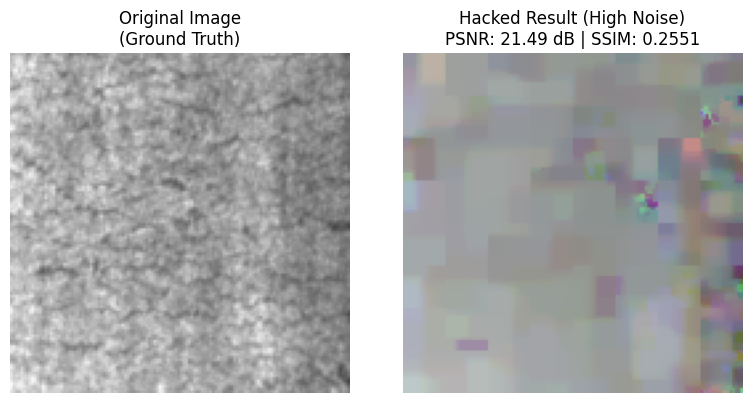

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models' # 请确认这里和你保存模型的文件夹一致
OUT_DIR = 'Attack_Results'
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明模型组件 (保持原样)
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        if self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
    if noise_std > 0.0:
        g = g + torch.randn_like(g) * noise_std
    return g

# ==========================================
# 2. 辅助函数
# ==========================================
def denorm(tensor):
    t = tensor.detach().cpu().squeeze(0).clamp(-1, 1)
    return (t * 0.5 + 0.5).permute(1, 2, 0).numpy()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    return 20 * np.log10(2.0 / np.sqrt(mse))

def total_variation_loss(img):
    tv_h = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    tv_w = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return tv_h + tv_w

# ==========================================
# 3. 高阶攻击核心逻辑
# ==========================================
def reconstruct_attack_advanced(client_model, real_img, config, iters=500):
    client_model.eval()
    
    # --- A. 截获数据 ---
    real_img = real_img.to(DEVICE).requires_grad_(True)
    
    # 🌟 开启高噪声前向防御
    client_model.forward_defense.noise_std = config['forward_noise']
    z_real = client_model(real_img)
    
    fake_loss = z_real.mean()
    fake_loss.backward(retain_graph=True)
    
    intercepted_z = z_real.detach().clone()
    intercepted_grad = apply_gradient_defense(real_img.grad, config['backward_prune'], config['backward_noise']).detach().clone()
    
    # --- B. 攻击优化 ---
    dummy_img = torch.randn_like(real_img).to(DEVICE).requires_grad_(True)
    optimizer = optim.Adam([dummy_img], lr=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    criterion = nn.MSELoss()
    
    # 黑客本地拟合时关闭防御
    client_model.forward_defense.noise_std = 0.0 
    
    process_snapshots = []
    log_intervals = [0, 50, 100, 200, 300, 499]
    
    for i in range(iters):
        optimizer.zero_grad()
        dummy_z = client_model(dummy_img)
        
        loss_z = criterion(dummy_z, intercepted_z)
        dummy_loss = dummy_z.mean()
        dummy_grad = torch.autograd.grad(dummy_loss, dummy_img, create_graph=True)[0]
        loss_g = criterion(dummy_grad, intercepted_grad)
        
        tv_penalty = 1e-3 * total_variation_loss(dummy_img)
        total_loss = loss_z + loss_g + tv_penalty
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
        if i in log_intervals:
            process_snapshots.append(denorm(dummy_img))
            
    final_psnr = calculate_psnr(real_img, dummy_img)
    
    # 🌟 新增：计算 SSIM
    # denorm 会把张量变成 [H, W, C] 格式的 numpy 数组，范围 0~1
    real_img_np = denorm(real_img)
    dummy_img_np = denorm(dummy_img)
    
    # data_range=1.0 是因为图像像素在 denorm 后被映射到了 0~1 之间
    final_ssim = ssim(real_img_np, dummy_img_np, channel_axis=2, data_range=1.0)
    
    print(f"   [Metric] PSNR: {final_psnr:.2f} dB")
    print(f"   [Metric] SSIM: {final_ssim:.4f} (越接近0防御越好!)")
    
    return dummy_img.detach(), final_psnr, final_ssim
    
    # 画过程图
    fig, axes = plt.subplots(1, len(log_intervals), figsize=(15, 3))
    fig.suptitle(f'Reconstruction Attack on HIGH NOISE Model (Final PSNR: {final_psnr:.2f}dB)', fontsize=14)
    for idx, ax in enumerate(axes):
        ax.imshow(process_snapshots[idx])
        ax.set_title(f'Iter {log_intervals[idx]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'Process_HighNoise_Defense.png'))
    plt.close()
    
    return dummy_img.detach(), final_psnr

# ==========================================
# 4. 执行攻击
# ==========================================
if __name__ == "__main__":
    print("="*60)
    print("🏴‍☠️ 针对【高噪声双向防御模型】发起终极重构攻击")
    print("="*60)
    
    # 替换为你真实存在的图片路径
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    if not os.path.exists(img_path):
        print(f"❌ 找不到图片: {img_path}")
        exit()
        
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    
    # 🌟 精确读取你刚刚保存的高噪声模型
    weight_path = os.path.join(SAVE_DIR, 'dual_defense_client_best_high.pth')
    
    if not os.path.exists(weight_path):
        print(f"❌ 找不到高噪声模型权重: {weight_path}")
        print("请检查你的 SAVE_DIR 是否一致！")
        exit()
        
    client_model = ClientModel().to(DEVICE)
    client_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    
    # 🌟 配置必须和训练时的高噪声参数一模一样，这样才能正确模拟拦截到的特征
    high_noise_config = {
        "forward_noise": 0.05,  
        "backward_prune": 0.5,
        "backward_noise": 0.01  
    }
    
    print("   [Attacker] 正在实施高级白盒重构攻击...")
    
    # 🌟 修改点 1：左边加一个 ssim_val 来接收第三个返回值
    dummy_img, psnr, ssim_val = reconstruct_attack_advanced(client_model, real_img, high_noise_config, iters=500)
    
    # 🌟 修改点 2：控制台打印加上 SSIM
    print(f"   🛡️ 攻击结束！最终 PSNR: {psnr:.2f} dB | SSIM: {ssim_val:.4f}")
    
    # 输出原图与攻击结果的直观对比图
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(denorm(real_img))
    axes[0].set_title("Original Image\n(Ground Truth)")
    axes[0].axis('off')
    
    axes[1].imshow(denorm(dummy_img))
    # 🌟 修改点 3：把 SSIM 的分数也写到图片的标题上，方便放进论文
    axes[1].set_title(f"Hacked Result (High Noise)\nPSNR: {psnr:.2f} dB | SSIM: {ssim_val:.4f}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'Final_Comparison_HighNoise.png'))
    
    print(f"\n✅ 完美收官！所有的攻击过程图和对比图已保存在 📂 ./{OUT_DIR}/ 文件夹下。")

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
# 🌟 引入 SSIM 计算库
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Ablation_Models' # 消融实验权重所在的文件夹
OUT_DIR = 'Attack_Results'
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明模型组件
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        if self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
    if noise_std > 0.0:
        g = g + torch.randn_like(g) * noise_std
    return g

# ==========================================
# 2. 辅助函数：反标准化、PSNR、TV Loss
# ==========================================
def denorm(tensor):
    """将 [-1, 1] 的张量转换回 [0, 1] 用于显示和计算 SSIM"""
    t = tensor.detach().cpu().squeeze(0).clamp(-1, 1)
    return (t * 0.5 + 0.5).permute(1, 2, 0).numpy()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    return 20 * np.log10(2.0 / np.sqrt(mse))

def total_variation_loss(img):
    tv_h = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    tv_w = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return tv_h + tv_w

# ==========================================
# 3. 高阶攻击算法 (新增 SSIM 计算)
# ==========================================
def reconstruct_attack_advanced(client_model, real_img, config, exp_name, iters=500):
    client_model.eval()
    
    # --- A. 截获数据 ---
    real_img = real_img.to(DEVICE).requires_grad_(True)
    client_model.forward_defense.noise_std = config['forward_noise']
    z_real = client_model(real_img)
    
    fake_loss = z_real.mean()
    fake_loss.backward(retain_graph=True)
    
    intercepted_z = z_real.detach().clone()
    intercepted_grad = apply_gradient_defense(real_img.grad, config['backward_prune'], config['backward_noise']).detach().clone()
    
    # --- B. 攻击优化 ---
    dummy_img = torch.randn_like(real_img).to(DEVICE).requires_grad_(True)
    
    optimizer = optim.Adam([dummy_img], lr=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    criterion = nn.MSELoss()
    
    client_model.forward_defense.noise_std = 0.0 
    
    print(f"   [Attacker] 正在实施高级白盒重构攻击 ({exp_name})...")
    
    for i in range(iters):
        optimizer.zero_grad()
        dummy_z = client_model(dummy_img)
        
        # 特征与梯度匹配损失
        loss_z = criterion(dummy_z, intercepted_z)
        dummy_loss = dummy_z.mean()
        dummy_grad = torch.autograd.grad(dummy_loss, dummy_img, create_graph=True)[0]
        loss_g = criterion(dummy_grad, intercepted_grad)
        
        tv_penalty = 1e-3 * total_variation_loss(dummy_img)
        total_loss = loss_z + loss_g + tv_penalty
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
    # 🌟 核心指标计算
    final_psnr = calculate_psnr(real_img, dummy_img)
    
    # 计算 SSIM (需要转成 [0, 1] 的 numpy 数组格式)
    real_img_np = denorm(real_img)
    dummy_img_np = denorm(dummy_img)
    final_ssim = ssim(real_img_np, dummy_img_np, channel_axis=2, data_range=1.0)
    
    return dummy_img.detach(), final_psnr, final_ssim

# ==========================================
# 4. 执行所有评估并生成总对比图
# ==========================================
def run_all_attacks():
    print("="*60)
    print("🏴‍☠️ 启动全消融实验攻击评估 (PSNR + SSIM 双重指标)")
    print("="*60)
    
    # 请确认此路径存在
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    if not os.path.exists(img_path):
        print(f"❌ 找不到图片: {img_path}")
        return
        
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    
    # 定义低噪声消融实验的四个配置
    experiments = {
        "Exp_A_Baseline": {"desc": "Baseline", "forward_noise": 0.0, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_B_ForwardOnly": {"desc": "Forward Perturb", "forward_noise": 1e-3, "backward_prune": 0.0, "backward_noise": 0.0},
        "Exp_C_BackwardOnly": {"desc": "Backward Prune+DP", "forward_noise": 0.0, "backward_prune": 0.5, "backward_noise": 1e-3},
        "Exp_D_DualDefense": {"desc": "Dual Defense", "forward_noise": 1e-3, "backward_prune": 0.5, "backward_noise": 1e-3}
    }
    
    results_psnr = {}
    results_ssim = {}
    reconstructed_imgs = {}
    client_model = ClientModel().to(DEVICE)
    
    for key, config in experiments.items():
        print(f"\n🎯 目标: {config['desc']}")
        weight_path = os.path.join(SAVE_DIR, f"{key}_client_best.pth")
        
        if not os.path.exists(weight_path):
            print(f"   ⚠️ 未找到权重: {weight_path}，请先跑消融代码！")
            continue
            
        client_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        
        # 接收三个返回值 (图片, PSNR, SSIM)
        dummy_img, psnr, ssim_val = reconstruct_attack_advanced(client_model, real_img, config, key, iters=500)
        
        results_psnr[config['desc']] = psnr
        results_ssim[config['desc']] = ssim_val
        reconstructed_imgs[config['desc']] = denorm(dummy_img)
        
        print(f"   🛡️ 攻击结束。 PSNR: {psnr:.2f} dB | SSIM: {ssim_val:.4f}")

    # 打印终端总结表格
    print("\n" + "="*60)
    print("📊 最终隐私防御能力评估报告")
    print("="*60)
    print(f"{'实验组别':<25} | {'PSNR (dB)':<12} | {'SSIM (越低越好)':<12}")
    print("-" * 60)
    for desc in results_psnr.keys():
        print(f"{desc:<25} | {results_psnr[desc]:<12.2f} | {results_ssim[desc]:<12.4f}")
    print("="*60)

    # 🌟 绘制带 SSIM 的总防守能力对比图
    if reconstructed_imgs:
        fig, axes = plt.subplots(1, len(reconstructed_imgs) + 1, figsize=(18, 4))
        fig.suptitle('Privacy Defense Capability Comparison (PSNR & SSIM)', fontsize=16, fontweight='bold')
        
        # 原图
        axes[0].imshow(denorm(real_img))
        axes[0].set_title("Original Image\n(Ground Truth)")
        axes[0].axis('off')
        
        # 各个重构结果
        for idx, (desc, img) in enumerate(reconstructed_imgs.items()):
            axes[idx+1].imshow(img)
            # 在标题中同时显示 PSNR 和 SSIM
            axes[idx+1].set_title(f"{desc}\nPSNR: {results_psnr[desc]:.2f} dB\nSSIM: {results_ssim[desc]:.4f}")
            axes[idx+1].axis('off')
            
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, 'Final_Defense_Comparison_with_SSIM.png'), dpi=300)
        plt.close()
        print(f"\n✅ 评估完成！包含双重指标的终极对比图已保存在 📂 ./{OUT_DIR}/ 文件夹下。")

if __name__ == "__main__":
    run_all_attacks()

🏴‍☠️ 启动全消融实验攻击评估 (PSNR + SSIM 双重指标)

🎯 目标: Baseline
   [Attacker] 正在实施高级白盒重构攻击 (Exp_A_Baseline)...
   🛡️ 攻击结束。 PSNR: 19.64 dB | SSIM: 0.2467

🎯 目标: Forward Perturb
   [Attacker] 正在实施高级白盒重构攻击 (Exp_B_ForwardOnly)...
   🛡️ 攻击结束。 PSNR: 19.90 dB | SSIM: 0.2389

🎯 目标: Backward Prune+DP
   [Attacker] 正在实施高级白盒重构攻击 (Exp_C_BackwardOnly)...
   🛡️ 攻击结束。 PSNR: 21.95 dB | SSIM: 0.2606

🎯 目标: Dual Defense
   [Attacker] 正在实施高级白盒重构攻击 (Exp_D_DualDefense)...
   🛡️ 攻击结束。 PSNR: 20.11 dB | SSIM: 0.2341

📊 最终隐私防御能力评估报告
实验组别                      | PSNR (dB)    | SSIM (越低越好) 
------------------------------------------------------------
Baseline                  | 19.64        | 0.2467      
Forward Perturb           | 19.90        | 0.2389      
Backward Prune+DP         | 21.95        | 0.2606      
Dual Defense              | 20.11        | 0.2341      

✅ 评估完成！包含双重指标的终极对比图已保存在 📂 ./Attack_Results/ 文件夹下。


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models' # 请确认这里和你保存模型的文件夹一致
# 🌟 创建全新的专属文件夹存放高清细节图
OUT_DIR = 'Attack_Results_HighNoise_Details'
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4

# ==========================================
# 1. 重新声明模型组件
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        if self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
    if noise_std > 0.0:
        g = g + torch.randn_like(g) * noise_std
    return g

# ==========================================
# 2. 辅助函数
# ==========================================
def denorm(tensor):
    t = tensor.detach().cpu().squeeze(0).clamp(-1, 1)
    return (t * 0.5 + 0.5).permute(1, 2, 0).numpy()

def calculate_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0: return float('inf')
    return 20 * np.log10(2.0 / np.sqrt(mse))

def total_variation_loss(img):
    tv_h = torch.sum(torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:]))
    tv_w = torch.sum(torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :]))
    return tv_h + tv_w

# ==========================================
# 3. 高阶攻击核心逻辑 (已修复 Return Bug 并独立保存)
# ==========================================
def reconstruct_attack_advanced(client_model, real_img, config, iters=500):
    client_model.eval()
    
    # --- A. 截获数据 ---
    real_img = real_img.to(DEVICE).requires_grad_(True)
    
    # 开启高噪声前向防御
    client_model.forward_defense.noise_std = config['forward_noise']
    z_real = client_model(real_img)
    
    fake_loss = z_real.mean()
    fake_loss.backward(retain_graph=True)
    
    intercepted_z = z_real.detach().clone()
    intercepted_grad = apply_gradient_defense(real_img.grad, config['backward_prune'], config['backward_noise']).detach().clone()
    
    # --- B. 攻击优化 ---
    dummy_img = torch.randn_like(real_img).to(DEVICE).requires_grad_(True)
    optimizer = optim.Adam([dummy_img], lr=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iters)
    criterion = nn.MSELoss()
    
    client_model.forward_defense.noise_std = 0.0 
    
    process_snapshots = []
    log_intervals = [0, 50, 100, 200, 300, 499]
    
    for i in range(iters):
        optimizer.zero_grad()
        dummy_z = client_model(dummy_img)
        
        loss_z = criterion(dummy_z, intercepted_z)
        dummy_loss = dummy_z.mean()
        dummy_grad = torch.autograd.grad(dummy_loss, dummy_img, create_graph=True)[0]
        loss_g = criterion(dummy_grad, intercepted_grad)
        
        tv_penalty = 1e-3 * total_variation_loss(dummy_img)
        total_loss = loss_z + loss_g + tv_penalty
        
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        
        with torch.no_grad():
            dummy_img.clamp_(-1.0, 1.0)
            
        if i in log_intervals:
            snap_img = denorm(dummy_img)
            process_snapshots.append(snap_img)
            # 🌟 单独保存每一轮迭代的纯净图片
            plt.imsave(os.path.join(OUT_DIR, f'Process_Iter_{i:03d}.png'), snap_img)
            
    final_psnr = calculate_psnr(real_img, dummy_img)
    
    # 计算 SSIM
    real_img_np = denorm(real_img)
    dummy_img_np = denorm(dummy_img)
    final_ssim = ssim(real_img_np, dummy_img_np, channel_axis=2, data_range=1.0)
    
    print(f"   [Metric] PSNR: {final_psnr:.2f} dB")
    print(f"   [Metric] SSIM: {final_ssim:.4f} (越接近0防御越好!)")
    
    # 🌟 单独保存原图和最终攻击出来的图
    plt.imsave(os.path.join(OUT_DIR, 'Final_Hacked_Image.png'), dummy_img_np)
    plt.imsave(os.path.join(OUT_DIR, 'Original_Image.png'), real_img_np)
    
    # 画全家福过程图 (方便整体预览)
    fig, axes = plt.subplots(1, len(log_intervals), figsize=(15, 3))
    fig.suptitle(f'Reconstruction Attack on HIGH NOISE Model (Final PSNR: {final_psnr:.2f}dB, SSIM: {final_ssim:.4f})', fontsize=14)
    for idx, ax in enumerate(axes):
        ax.imshow(process_snapshots[idx])
        ax.set_title(f'Iter {log_intervals[idx]}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'Combined_Process_HighNoise.png'))
    plt.close()
    
    # 🌟 修复后的 Return：放到画完图之后
    return dummy_img.detach(), final_psnr, final_ssim

# ==========================================
# 4. 执行攻击
# ==========================================
if __name__ == "__main__":
    print("="*60)
    print("🏴‍☠️ 针对【高噪声双向防御模型】发起终极重构攻击")
    print("="*60)
    
    # 替换为你真实存在的图片路径
    img_path = r'/root/autodl-tmp/exp2/data/NEU/IMAGES/crazing_1.jpg' 
    if not os.path.exists(img_path):
        print(f"❌ 找不到图片: {img_path}")
        exit()
        
    img_pil = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    real_img = transform(img_pil).unsqueeze(0)
    
    # 精确读取你刚刚保存的高噪声模型
    weight_path = os.path.join(SAVE_DIR, 'dual_defense_client_best_high.pth')
    
    if not os.path.exists(weight_path):
        print(f"❌ 找不到高噪声模型权重: {weight_path}")
        print("请检查你的 SAVE_DIR 是否一致！")
        exit()
        
    client_model = ClientModel().to(DEVICE)
    client_model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    
    # 🌟 强防御的高噪声配置
    high_noise_config = {
        "forward_noise": 0.05,  
        "backward_prune": 0.5,
        "backward_noise": 0.01  
    }
    
    print("   [Attacker] 正在实施高级白盒重构攻击...")
    
    # 获取所有的结果
    dummy_img, psnr, ssim_val = reconstruct_attack_advanced(client_model, real_img, high_noise_config, iters=500)
    
    print(f"   🛡️ 攻击结束！最终 PSNR: {psnr:.2f} dB | SSIM: {ssim_val:.4f}")
    
    # 输出原图与攻击结果的直观对比长图
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(denorm(real_img))
    axes[0].set_title("Original Image\n(Ground Truth)")
    axes[0].axis('off')
    
    axes[1].imshow(denorm(dummy_img))
    axes[1].set_title(f"Hacked Result (High Noise)\nPSNR: {psnr:.2f} dB | SSIM: {ssim_val:.4f}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'Combined_Comparison_HighNoise.png'))
    plt.close()
    
    print(f"\n✅ 完美收官！")
    print(f"📂 所有的单张演变图、原图、纯净攻击图均已保存在 ./{OUT_DIR}/ 文件夹下！")

🏴‍☠️ 针对【高噪声双向防御模型】发起终极重构攻击
   [Attacker] 正在实施高级白盒重构攻击...
   [Metric] PSNR: 22.52 dB
   [Metric] SSIM: 0.2761 (越接近0防御越好!)
   🛡️ 攻击结束！最终 PSNR: 22.52 dB | SSIM: 0.2761

✅ 完美收官！
📂 所有的单张演变图、原图、纯净攻击图均已保存在 ./Attack_Results_HighNoise_Details/ 文件夹下！


📊 启动单类别精度评估与混淆矩阵生成
🔍 正在测试集中进行推理计算...

🎯 单类别准确率报告 (Per-Class Accuracy)
缺陷类别                 | 准确率             | 测试样本数
--------------------------------------------------
Crazing              | 92.98%          | 57
Inclusion            | 79.59%          | 49
Patches              | 100.00%         | 63
Pitted               | 89.47%          | 57
Rolled               | 91.04%          | 67
Scratches            | 91.04%          | 67
--------------------------------------------------
🌟 全局总准确率: 91.11%

✅ 混淆矩阵图已保存至: Evaluation_Results/Confusion_Matrix_HighNoise.png


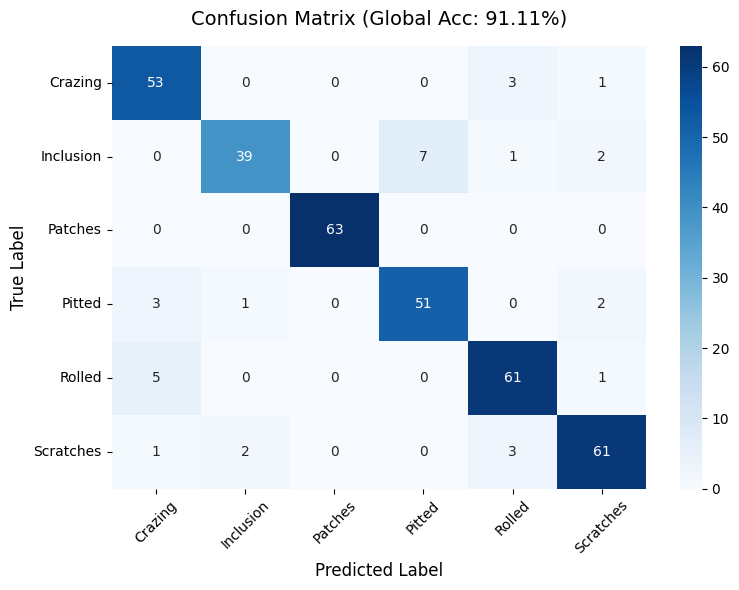

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import glob

# ==========================================
# 0. 全局配置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models'  # 如果你要测消融模型，这里改成 'Ablation_Models'
OUT_DIR = 'Evaluation_Results'
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES = 6
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']

# 数据路径 (请替换为真实路径)
DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 

# ==========================================
# 1. 模型结构 (推理专用，省略训练机制)
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0
    def forward(self, x):
        # 推理阶段 (eval) 不加噪
        if self.training and self.noise_std > 0:
            return x + torch.randn_like(x) * self.noise_std
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)
    def forward(self, x):
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 数据集加载 (仅保留测试集逻辑)
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_test_loader(root):
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
                    
    # 固定随机种子保证测试集划分与训练时完全一致
    np.random.seed(42)
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    test_idx = indices[split_idx:]
    
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    test_dataset = NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test)
    return DataLoader(test_dataset, batch_size=64, shuffle=False)

# ==========================================
# 3. 核心评估流程
# ==========================================
def evaluate_model():
    print("="*60)
    print("📊 启动单类别精度评估与混淆矩阵生成")
    print("="*60)
    
    # 🌟 在这里指定你想评估的模型权重
    # 比如你想看高噪声模型的，就用这个名字：
    client_weight = os.path.join(SAVE_DIR, 'dual_defense_client_best.pth')
    server_weight = os.path.join(SAVE_DIR, 'dual_defense_server_best.pth')
    
    if not os.path.exists(client_weight):
        print(f"❌ 找不到权重文件: {client_weight}")
        return

    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES).to(DEVICE)
    
    client.load_state_dict(torch.load(client_weight, map_location=DEVICE))
    server.load_state_dict(torch.load(server_weight, map_location=DEVICE))
    
    client.eval(); server.eval()
    test_loader = get_test_loader(DATA_ROOT)
    
    all_preds = []
    all_labels = []
    
    print("🔍 正在测试集中进行推理计算...")
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            # 拆分模型的端到端前向传播
            logits = server(client(imgs))
            _, preds = torch.max(logits, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    
    # 计算每个类别的准确率
    class_acc = cm.diagonal() / cm.sum(axis=1)
    
    # 打印控制台表格
    print("\n" + "="*50)
    print("🎯 单类别准确率报告 (Per-Class Accuracy)")
    print("="*50)
    print(f"{'缺陷类别':<20} | {'准确率':<15} | {'测试样本数'}")
    print("-" * 50)
    for idx, cls_name in enumerate(CLASSES):
        acc_str = f"{class_acc[idx]*100:.2f}%"
        print(f"{cls_name.capitalize():<20} | {acc_str:<15} | {cm.sum(axis=1)[idx]}")
    print("-" * 50)
    global_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"🌟 全局总准确率: {global_acc*100:.2f}%\n")
    
    # 🌟 绘制并保存漂亮的混淆矩阵图
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[c.capitalize() for c in CLASSES], 
                yticklabels=[c.capitalize() for c in CLASSES])
    plt.title(f'Confusion Matrix (Global Acc: {global_acc*100:.2f}%)', fontsize=14, pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    cm_save_path = os.path.join(OUT_DIR, 'Confusion_Matrix_HighNoise.png')
    plt.savefig(cm_save_path, dpi=300)
    print(f"✅ 混淆矩阵图已保存至: {cm_save_path}")

if __name__ == '__main__':
    evaluate_model()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import glob
import time
import datetime
from PIL import Image

# ==========================================
# 0. 全局配置与保存路径
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Dual_Defense_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

# 确保实验可复现 (毕设必备)
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True # 针对固定尺寸输入加速
set_seed(42)

print(f"🚀 Running on: {DEVICE}")
print(f"📂 Models will be saved to: ./{SAVE_DIR}/")

# ViT 超参数
IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10 # CIFAR-10
NUM_CLASSES_FINETUNE = 6  # NEU-DET

# ==========================================
# 1. 核心架构与【前向特征防御】
# ==========================================
class ForwardDefense(nn.Module):
    """
    【前向防御】(原 MockHE)
    作用：在边缘端特征 Z 上传云端前注入高斯噪声，防御云端的特征逆向重构攻击。
    """
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0 # 预训练时默认关闭 (0.0)，微调时开启

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    """标准的 Transformer Block，使用原生 GELU 激活函数提取最佳特征"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(), 
            nn.Linear(dim * 2, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    """边缘端模型：物理截留原始钢材图像，仅输出加噪特征"""
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        # 边缘端持有前 2 层 Block
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        # 接入前向特征防御
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: 
            x = blk(x)
        # 流出边缘端前进行噪声扰动
        return self.forward_defense(x)

class ServerModel(nn.Module):
    """云端模型：接收中间特征 Z，完成高层语义推断与分类"""
    def __init__(self, num_classes=10):
        super().__init__()
        # 云端持有后 2 层 Block + 分类头
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: 
            x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

# ==========================================
# 2. 数据处理与【反向梯度防御】
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self): 
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        try: 
            img = Image.open(self.file_paths[idx]).convert('RGB')
        except: 
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: 
            img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    """集中式加载并打乱 NEU-DET 数据集 (80% 训练, 20% 测试)"""
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path)
                    labels.append(cls_map[c])
                    break
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    train_loader = DataLoader(
        NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), 
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), 
        batch_size=64, shuffle=False
    )
    
    return train_loader, test_loader

def apply_gradient_defense(grad, prune_ratio=0.5, noise_std=1e-3):
    """
    【反向防御】幅度稀疏化 + 差分隐私加噪
    作用：防止云端利用回传梯度反推边缘端的原始图像 (Model Inversion Attack)。
    """
    if grad is None: 
        return None
    g = grad.detach().clone()
    
    # 1. 梯度剪枝 (过滤掉微小的细节梯度)
    k = int(g.numel() * (1 - prune_ratio))
    if k > 0:
        thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
        mask = g.abs() >= thresh
        g = g * mask
        
    # 2. 差分隐私加噪 (掩盖真实分布)
    noise = torch.randn_like(g) * noise_std
    
    return g + noise

# ==========================================
# 3. 终极训练流程：预训练 -> 双向隐私微调
# ==========================================
def run_ultimate_pipeline():
    # --- A. 阶段 1：全量云端预训练 (CIFAR-10) ---
    print("\n☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...")
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-3)
    opt_s = optim.AdamW(server.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    tf_cifar = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)), 
        transforms.ToTensor(), 
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
    cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
    
    t_start = time.time()
    for epoch in range(1, 4):
        client.train(); server.train()
        total_loss = 0
        for imgs, labels in cifar_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            # 前向传播 (此时 forward_defense 默认关闭)
            z = client(imgs)
            logits = server(z)
            
            loss = criterion(logits, labels)
            loss.backward()
            opt_c.step(); opt_s.step()
            total_loss += loss.item()
            
        print(f"   Epoch {epoch} (Pre-train) Finished. Avg Loss: {total_loss/len(cifar_loader):.4f}")
        
    print(f"✅ Pre-training Time: {(time.time() - t_start)/60:.1f} minutes")
    
    # --- B. 准备双向防御微调 ---
    print("\n🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...")
    
    # 换头手术 (适配 6 类缺陷)
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    
    # 🌟 开启双向防御之一：前向特征加噪
    client.forward_defense.noise_std = 1e-3
    print("   🛡️ Forward Feature Perturbation: ENABLED")
    print("   🛡️ Backward Gradient DP & Pruning: ENABLED")
    
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    # 请填入实际的 NEU 数据集路径
    DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    # --- C. 核心微调循环 ---
    best_acc = 0.0
    EPOCHS = 50 
    
    # 🌟 1. 在循环外建立两个空列表，用来当“记事本”
    history_loss = []
    history_acc = []
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        
        epoch_loss_sum = 0.0 # 🌟 用来累加一轮里所有 batch 的 loss
        batch_count = 0
        
        # --- 训练阶段 ---
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone().requires_grad_(True)
            
            logits = server(z_payload)
            loss = criterion(logits, labels)
            
            epoch_loss_sum += loss.item() # 🌟 累加 loss
            batch_count += 1
            
            loss.backward()
            safe_grad = apply_gradient_defense(z_payload.grad, prune_ratio=0.5, noise_std=0.01)
            opt_s.step() 
            z.backward(safe_grad)
            opt_c.step() 
            
        # 🌟 2. 计算这一轮的平均 Loss 并记录
        avg_train_loss = epoch_loss_sum / batch_count
        history_loss.append(avg_train_loss)
            
        # --- 全局评估阶段 ---
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        history_acc.append(acc) # 🌟 3. 记录这一轮的准确率
        
        # 打印单轮汇总信息
        print(f"   Epoch {epoch:02d} | Loss: {avg_train_loss:.4f} | 🏆 Test Acc: {acc:.2f}%")
        
        # --- 保存最佳模型 ---
        if acc > best_acc:
            best_acc = acc
            import datetime
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            # 这里的名字可以根据你跑的实验自己调整
            torch.save(client.state_dict(), f'{SAVE_DIR}/dual_defense_client_best_v1.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/dual_defense_server_best_v1.pth')
            print(f"      🔥 New Best! Model Saved. ({best_acc:.2f}%)")

    # ==========================================
    # 循环彻底结束后执行的收尾工作
    # ==========================================
    print(f"\n✅ Experiment Finished. Final Best Accuracy: {best_acc:.2f}%")
    print(f"📂 Models are ready in: {SAVE_DIR}")
    
    # 🌟 4. 把这两个“记事本”保存为 numpy 文件，供后面画图用
    np.save(f'{SAVE_DIR}/history_dual_defense_high.npy', {
        'loss': history_loss,
        'acc': history_acc
    })
    print("💾 训练历史曲线数据已保存！")

if __name__ == '__main__':
    run_ultimate_pipeline()

🚀 Running on: cuda
📂 Models will be saved to: ./Dual_Defense_Models/

☁️ [Stage 1] Massive Pre-training on CIFAR-10 (Standard Feature Extraction)...
Files already downloaded and verified
   Epoch 1 (Pre-train) Finished. Avg Loss: 1.8694
   Epoch 2 (Pre-train) Finished. Avg Loss: 1.6191
   Epoch 3 (Pre-train) Finished. Avg Loss: 1.5060
✅ Pre-training Time: 0.8 minutes

🏭 [Stage 2] Edge-Cloud Collaborative Finetuning with Dual Defense...
   🛡️ Forward Feature Perturbation: ENABLED
   🛡️ Backward Gradient DP & Pruning: ENABLED
   Epoch 01 | Loss: 1.6073 | 🏆 Test Acc: 56.67%
      🔥 New Best! Model Saved. (56.67%)
   Epoch 02 | Loss: 1.2549 | 🏆 Test Acc: 68.89%
      🔥 New Best! Model Saved. (68.89%)
   Epoch 03 | Loss: 1.0401 | 🏆 Test Acc: 70.00%
      🔥 New Best! Model Saved. (70.00%)
   Epoch 04 | Loss: 0.8782 | 🏆 Test Acc: 73.33%
      🔥 New Best! Model Saved. (73.33%)
   Epoch 05 | Loss: 0.7599 | 🏆 Test Acc: 78.89%
      🔥 New Best! Model Saved. (78.89%)
   Epoch 06 | Loss: 0.6667 | 🏆

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import os
import glob
import datetime

# ==========================================
# 0. 全局配置与复现设置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = 'Ablation_Models_Final'
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10
NUM_CLASSES_FINETUNE = 6

# 🌟 请确认你的 NEU-DET 数据集真实路径
DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 

# ==========================================
# 1. 核心架构与防御机制
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    
    if prune_ratio == 0.0 and noise_std == 0.0:
        return g
        
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
            
    if noise_std > 0.0:
        noise = torch.randn_like(g) * noise_std
        g = g + noise
        
    return g

# ==========================================
# 2. 数据处理
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
    
    # 保证每次划分一致
    np.random.seed(42)
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    train_loader = DataLoader(NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), batch_size=64, shuffle=False)
    
    return train_loader, test_loader

# ==========================================
# 3. 终极实验引擎 (支持全部变量控制与曲线记录)
# ==========================================
def run_experiment(exp_key, config):
    print(f"\n" + "="*60)
    print(f"🔬 启动实验: {config['desc']}")
    print(f"   参数配置: {config}")
    print("="*60)
    
    # 确保每个实验起点完全一致
    set_seed(42)
    
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    
    # --- Stage 1: 预训练控制 ---
    if config.get('use_pretrain', True):
        print("☁️ [Stage 1] 开启预训练 (Pre-training on CIFAR-10 proxy)...")
        opt_c_pre = optim.AdamW(client.parameters(), lr=1e-3)
        opt_s_pre = optim.AdamW(server.parameters(), lr=1e-3)
        
        tf_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
        
        for epoch in range(1, 4): 
            client.train(); server.train()
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c_pre.zero_grad(); opt_s_pre.zero_grad()
                loss = criterion(server(client(imgs)), labels)
                loss.backward()
                opt_c_pre.step(); opt_s_pre.step()
    else:
        print("⏭️ [Stage 1] 跳过预训练 (Train from Scratch 直接在目标数据集上训练)...")
    
    # --- Stage 2: 目标数据集微调 ---
    print(f"🏭 [Stage 2] 开始在 NEU-DET 上微调...")
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    
    # 注入前向防御参数
    client.forward_defense.noise_std = config['forward_noise']
    
    best_acc = 0.0
    EPOCHS = 50
    
    # 🌟 初始化记录器
    history_loss = []
    history_acc = []
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        epoch_loss_sum = 0.0
        batch_count = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone().requires_grad_(True)
            
            logits = server(z_payload)
            loss = criterion(logits, labels)
            
            epoch_loss_sum += loss.item()
            batch_count += 1
            
            loss.backward()
            
            # 注入反向防御参数
            safe_grad = apply_gradient_defense(
                z_payload.grad, 
                prune_ratio=config['backward_prune'], 
                noise_std=config['backward_noise']
            )
            
            opt_s.step() 
            z.backward(safe_grad)
            opt_c.step() 
            
        # 记录本轮平均 Loss
        avg_train_loss = epoch_loss_sum / batch_count
        history_loss.append(avg_train_loss)
            
        # 全局评估
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        history_acc.append(acc)
        
        print(f"   Epoch {epoch:02d} | Loss: {avg_train_loss:.4f} | 🏆 Test Acc: {acc:.2f}%")
        
        # 保存最佳模型
        if acc > best_acc:
            best_acc = acc
            torch.save(client.state_dict(), f'{SAVE_DIR}/{exp_key}_client_best.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/{exp_key}_server_best.pth')

    print(f"✅ {config['desc']} 运行结束. 最高准确率: {best_acc:.2f}%")
    
    # 保存历史曲线数据供画图使用
    # ==========================================
    # 循环彻底结束后执行的收尾工作
    # ==========================================
    print(f"\n✅ Experiment Finished. Final Best Accuracy: {best_acc:.2f}%")
    print(f"📂 Models are ready in: {SAVE_DIR}")
    
    # 🌟 4. 将记录的数据保存为一目了然的 txt 文件 (逗号分隔，方便复制进 Excel)
    txt_path = f'{SAVE_DIR}/history_dual_defense_high.txt'
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("Epoch,Loss,Accuracy\n") # 写入表头
        for i in range(len(history_loss)):
            f.write(f"{i+1},{history_loss[i]:.6f},{history_acc[i]:.6f}\n")
            
    print(f"💾 训练历史曲线数据已保存为纯文本: {txt_path}")
    
    return best_acc

# ==========================================
# 4. 执行所有消融实验组合
# ==========================================
if __name__ == '__main__':
    # 🌟 这里是你所有的实验配置大全！
    experiments = {
        "Exp_A_Baseline": {
            "desc": "基准模型 (有预训练, 无防御)",
            "forward_noise": 0.0, "backward_prune": 0.0, "backward_noise": 0.0,
            "use_pretrain": False
        },
        "Exp_B_ForwardOnly": {
            "desc": "仅前向防御 (有预训练, 仅加噪特征)",
            "forward_noise": 0.05, "backward_prune": 0.0, "backward_noise": 0.0,
            "use_pretrain": True
        },
        "Exp_C_BackwardOnly": {
            "desc": "仅反向防御 (有预训练, 仅剪枝+加噪梯度)",
            "forward_noise": 0.0, "backward_prune": 0.5, "backward_noise": 0.01,
            "use_pretrain": True
        },
        "Exp_D_DualDefense": {
            "desc": "本文方法 (有预训练, 双向低噪防御)",
            "forward_noise": 0.1, "backward_prune": 0.5, "backward_noise": 0.1,
            "use_pretrain": True
        },
        "Exp_E_Scratch": {
            "desc": "无预训练消融 (无预训练, 双向低噪防御)",
            "forward_noise": 1e-3, "backward_prune": 0.5, "backward_noise": 1e-3,
            "use_pretrain": False   # 🌟 关键消融变量：关闭预训练
        }
    }
    
    results = {}
    
    print("\n🚀 启动批量消融训练流水线...")
    # 依次执行上面的字典里的每一个实验
    for key, config in experiments.items():
        best_acc = run_experiment(key, config)
        results[config['desc']] = best_acc
        
    # 输出最终的实验报告
    print("\n\n" + "="*60)
    print("📊 最终消融实验分类准确率报告")
    print("="*60)
    print(f"{'实验组别':<40} | {'最佳准确率 (Best Acc)'}")
    print("-" * 60)
    for desc, acc in results.items():
        print(f"{desc:<40} | {acc:>15.2f}%")
    print("="*60)
    print(f"📂 所有的模型权重 (.pth) 与曲线数据 (.npy) 均已存入 ./{SAVE_DIR}/ 文件夹！")


🚀 启动批量消融训练流水线...

🔬 启动实验: 基准模型 (有预训练, 无防御)
   参数配置: {'desc': '基准模型 (有预训练, 无防御)', 'forward_noise': 0.0, 'backward_prune': 0.0, 'backward_noise': 0.0, 'use_pretrain': False}
⏭️ [Stage 1] 跳过预训练 (Train from Scratch 直接在目标数据集上训练)...
🏭 [Stage 2] 开始在 NEU-DET 上微调...
   Epoch 01 | Loss: 1.2805 | 🏆 Test Acc: 60.83%
   Epoch 02 | Loss: 0.9793 | 🏆 Test Acc: 64.17%
   Epoch 03 | Loss: 0.8236 | 🏆 Test Acc: 71.11%
   Epoch 04 | Loss: 0.6895 | 🏆 Test Acc: 68.33%
   Epoch 05 | Loss: 0.7006 | 🏆 Test Acc: 75.28%
   Epoch 06 | Loss: 0.4874 | 🏆 Test Acc: 81.94%
   Epoch 07 | Loss: 0.4224 | 🏆 Test Acc: 78.33%
   Epoch 08 | Loss: 0.3908 | 🏆 Test Acc: 81.39%
   Epoch 09 | Loss: 0.3396 | 🏆 Test Acc: 86.67%
   Epoch 10 | Loss: 0.3076 | 🏆 Test Acc: 87.50%
   Epoch 11 | Loss: 0.2502 | 🏆 Test Acc: 83.61%
   Epoch 12 | Loss: 0.2776 | 🏆 Test Acc: 85.83%
   Epoch 13 | Loss: 0.2250 | 🏆 Test Acc: 90.83%
   Epoch 14 | Loss: 0.1961 | 🏆 Test Acc: 87.78%
   Epoch 15 | Loss: 0.2172 | 🏆 Test Acc: 91.39%
   Epoch 16 | Loss: 0

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import os
import glob

# ==========================================
# 0. 全局配置与复现设置
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# 🌟 专门为剪枝率实验建一个新文件夹，防止覆盖之前的主实验
SAVE_DIR = 'Ablation_Pruning_Results'
os.makedirs(SAVE_DIR, exist_ok=True)

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if DEVICE == 'cuda':
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
NUM_HEADS = 4
NUM_CLASSES_PRETRAIN = 10
NUM_CLASSES_FINETUNE = 6

# 🌟 请确认你的 NEU-DET 数据集真实路径
DATA_ROOT = r'/root/autodl-tmp/exp2/data/NEU/IMAGES' 

# ==========================================
# 1. 核心架构与防御机制
# ==========================================
class ForwardDefense(nn.Module):
    def __init__(self):
        super().__init__()
        self.noise_std = 0.0

    def forward(self, x):
        if self.training and self.noise_std > 0:
            noise = torch.randn_like(x) * self.noise_std
            return x + noise
        return x

class StandardBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        num_patches = (IMG_SIZE // PATCH_SIZE) ** 2
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, EMBED_DIM) * .02)
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.forward_defense = ForwardDefense()

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.forward_defense(x)

class ServerModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.blocks = nn.ModuleList([StandardBlock(EMBED_DIM, NUM_HEADS) for _ in range(2)])
        self.norm = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, num_classes)

    def forward(self, x):
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        return self.head(x.mean(dim=1))

def apply_gradient_defense(grad, prune_ratio, noise_std):
    if grad is None: return None
    g = grad.detach().clone()
    
    if prune_ratio == 0.0 and noise_std == 0.0:
        return g
        
    if prune_ratio > 0.0:
        k = int(g.numel() * (1 - prune_ratio))
        if k > 0:
            thresh = torch.kthvalue(g.abs().flatten(), g.numel() - k + 1).values
            mask = g.abs() >= thresh
            g = g * mask
            
    if noise_std > 0.0:
        noise = torch.randn_like(g) * noise_std
        g = g + noise
        
    return g

# ==========================================
# 2. 数据处理
# ==========================================
class NEUDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx):
        try: img = Image.open(self.file_paths[idx]).convert('RGB')
        except: img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def load_centralized_data(root):
    CLASSES = ['crazing', 'inclusion', 'patches', 'pitted', 'rolled', 'scratches']
    cls_map = {c: i for i, c in enumerate(CLASSES)}
    files, labels = [], []
    for ext in ['*.jpg', '*.png', '*.bmp']:
        for path in glob.glob(os.path.join(root, ext)):
            name = os.path.basename(path).lower()
            for c in CLASSES:
                if c in name or (c=='scratches' and 'sc_' in name):
                    files.append(path); labels.append(cls_map[c]); break
    
    np.random.seed(42)
    indices = np.random.permutation(len(files))
    split_idx = int(len(files) * 0.8)
    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    transform_test = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    train_loader = DataLoader(NEUDataset([files[i] for i in train_idx], [labels[i] for i in train_idx], transform_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(NEUDataset([files[i] for i in test_idx], [labels[i] for i in test_idx], transform_test), batch_size=64, shuffle=False)
    
    return train_loader, test_loader

# ==========================================
# 3. 终极实验引擎
# ==========================================
def run_experiment(exp_key, config):
    print(f"\n" + "="*60)
    print(f"🔬 启动实验: {config['desc']}")
    print(f"   参数配置: {config}")
    print("="*60)
    
    set_seed(42)
    client = ClientModel().to(DEVICE)
    server = ServerModel(num_classes=NUM_CLASSES_PRETRAIN).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    
    # --- Stage 1: 预训练控制 ---
    if config.get('use_pretrain', True):
        print("☁️ [Stage 1] 开启预训练 (Pre-training on CIFAR-10 proxy)...")
        opt_c_pre = optim.AdamW(client.parameters(), lr=1e-3)
        opt_s_pre = optim.AdamW(server.parameters(), lr=1e-3)
        
        tf_cifar = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        cifar_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=tf_cifar)
        cifar_loader = DataLoader(cifar_set, batch_size=128, shuffle=True, num_workers=2)
        
        for epoch in range(1, 4): 
            client.train(); server.train()
            for imgs, labels in cifar_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                opt_c_pre.zero_grad(); opt_s_pre.zero_grad()
                loss = criterion(server(client(imgs)), labels)
                loss.backward()
                opt_c_pre.step(); opt_s_pre.step()
    else:
        print("⏭️ [Stage 1] 跳过预训练 (Train from Scratch)...")
    
    # --- Stage 2: 目标数据集微调 ---
    print(f"🏭 [Stage 2] 开始在 NEU-DET 上微调...")
    server.head = nn.Linear(EMBED_DIM, NUM_CLASSES_FINETUNE).to(DEVICE)
    opt_c = optim.AdamW(client.parameters(), lr=1e-4)
    opt_s = optim.AdamW(server.parameters(), lr=1e-4)
    
    train_loader, test_loader = load_centralized_data(DATA_ROOT)
    client.forward_defense.noise_std = config['forward_noise']
    
    best_acc = 0.0
    EPOCHS = 50
    history_loss = []
    history_acc = []
    
    for epoch in range(1, EPOCHS + 1):
        client.train(); server.train()
        epoch_loss_sum = 0.0
        batch_count = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_c.zero_grad(); opt_s.zero_grad()
            
            z = client(imgs)
            z_payload = z.detach().clone().requires_grad_(True)
            
            logits = server(z_payload)
            loss = criterion(logits, labels)
            
            epoch_loss_sum += loss.item()
            batch_count += 1
            
            loss.backward()
            
            safe_grad = apply_gradient_defense(
                z_payload.grad, 
                prune_ratio=config['backward_prune'], 
                noise_std=config['backward_noise']
            )
            
            opt_s.step() 
            z.backward(safe_grad)
            opt_c.step() 
            
        avg_train_loss = epoch_loss_sum / batch_count
        history_loss.append(avg_train_loss)
            
        client.eval(); server.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = server(client(imgs))
                _, predicted = torch.max(logits, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        acc = 100 * correct / total
        history_acc.append(acc)
        
        print(f"   Epoch {epoch:02d} | Loss: {avg_train_loss:.4f} | 🏆 Test Acc: {acc:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(client.state_dict(), f'{SAVE_DIR}/{exp_key}_client_best.pth')
            torch.save(server.state_dict(), f'{SAVE_DIR}/{exp_key}_server_best.pth')

    print(f"✅ {config['desc']} 运行结束. 最高准确率: {best_acc:.2f}%")
    
    # 🌟 将记录的数据保存为纯 txt 文件
    txt_path = f'{SAVE_DIR}/history_{exp_key}.txt'
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write("Epoch,Loss,Accuracy\n")
        for i in range(len(history_loss)):
            f.write(f"{i+1},{history_loss[i]:.6f},{history_acc[i]:.6f}\n")
            
    print(f"💾 训练历史曲线数据已保存为纯文本: {txt_path}")
    return best_acc

# ==========================================
# 4. 执行剪枝率超参数敏感性分析
# ==========================================
if __name__ == '__main__':
    # 🌟 专门针对剪枝率的超参数实验配置
    # 锁定：前向噪声 1e-3，反向噪声 1e-3，开启预训练。仅改变 backward_prune！
    pruning_experiments = {
        "Prune_0.0": {
            "desc": "剪枝率 0.0 (全量梯度保留)",
            "forward_noise": 1e-3, "backward_prune": 0.0, "backward_noise": 1e-3, "use_pretrain": True
        },
        "Prune_0.3": {
            "desc": "剪枝率 0.3 (保留 70% 梯度)",
            "forward_noise": 1e-3, "backward_prune": 0.3, "backward_noise": 1e-3, "use_pretrain": True
        },
        "Prune_0.5": {
            "desc": "剪枝率 0.5 (本文主设, 保留 50%)",
            "forward_noise": 1e-3, "backward_prune": 0.5, "backward_noise": 1e-3, "use_pretrain": True
        },
        "Prune_0.7": {
            "desc": "剪枝率 0.7 (保留 30% 梯度)",
            "forward_noise": 1e-3, "backward_prune": 0.7, "backward_noise": 1e-3, "use_pretrain": True
        },
        "Prune_0.9": {
            "desc": "剪枝率 0.9 (极限剪枝, 仅保留 10%)",
            "forward_noise": 1e-3, "backward_prune": 0.9, "backward_noise": 1e-3, "use_pretrain": True
        }
    }
    
    results = {}
    
    print("\n🚀 启动剪枝率超参数敏感性分析流水线...")
    for key, config in pruning_experiments.items():
        best_acc = run_experiment(key, config)
        results[config['desc']] = best_acc
        
    print("\n\n" + "="*60)
    print("📊 剪枝率敏感性分析最终报告")
    print("="*60)
    print(f"{'实验组别':<35} | {'最佳准确率 (Best Acc)'}")
    print("-" * 60)
    for desc, acc in results.items():
        print(f"{desc:<35} | {acc:>15.2f}%")
    print("="*60)
    print(f"📂 本次超参数实验的 .pth 权重与 .txt 曲线数据均已存入 ./{SAVE_DIR}/ 文件夹！")


🚀 启动剪枝率超参数敏感性分析流水线...

🔬 启动实验: 剪枝率 0.0 (全量梯度保留)
   参数配置: {'desc': '剪枝率 0.0 (全量梯度保留)', 'forward_noise': 0.001, 'backward_prune': 0.0, 'backward_noise': 0.001, 'use_pretrain': True}
☁️ [Stage 1] 开启预训练 (Pre-training on CIFAR-10 proxy)...
Files already downloaded and verified
🏭 [Stage 2] 开始在 NEU-DET 上微调...
   Epoch 01 | Loss: 1.5895 | 🏆 Test Acc: 53.06%
   Epoch 02 | Loss: 1.2545 | 🏆 Test Acc: 67.50%
   Epoch 03 | Loss: 1.0401 | 🏆 Test Acc: 69.44%
   Epoch 04 | Loss: 0.8988 | 🏆 Test Acc: 73.06%
   Epoch 05 | Loss: 0.7654 | 🏆 Test Acc: 76.67%
   Epoch 06 | Loss: 0.6541 | 🏆 Test Acc: 78.61%
   Epoch 07 | Loss: 0.5885 | 🏆 Test Acc: 81.39%
   Epoch 08 | Loss: 0.4993 | 🏆 Test Acc: 81.94%
   Epoch 09 | Loss: 0.4587 | 🏆 Test Acc: 83.33%
   Epoch 10 | Loss: 0.4330 | 🏆 Test Acc: 84.17%
   Epoch 11 | Loss: 0.4102 | 🏆 Test Acc: 83.33%
   Epoch 12 | Loss: 0.3880 | 🏆 Test Acc: 84.17%
   Epoch 13 | Loss: 0.3719 | 🏆 Test Acc: 83.33%
   Epoch 14 | Loss: 0.3481 | 🏆 Test Acc: 84.44%
   Epoch 15 | Loss: 0.3